This notebook is intended to be run in a Jupyter environment.  It
investigates how the yeast interactome responds locally when
chaperones are removed from the communities (modules) in which they
occur.  Previous notebooks established that chaperones are
concentrated in a handful of modules and act as locally central nodes.
Here we move beyond global robustness to ask: **what happens inside
each module when its chaperones are deleted?**

The main steps are:

1. Load the interactome and community assignments (from greedy
   modularity).  Identify which communities contain chaperones.
2. Compute baseline connectivity metrics for each chaperone-containing
   module: size of largest connected component (LCC), number of
   connected components, global efficiency, transitivity and
   approximate average path length.
3. For each module, remove all chaperones and recompute the same
   metrics.  Compare to baseline to quantify the local impact of
   chaperone removal.
4. As a control, perform random removals of the same number of nodes
   within each module (excluding chaperones) and repeat the
   computation multiple times.  This produces a null distribution for
   the effect of removing nodes at random.
5. Summarise and visualise the results across modules.  For each
   metric, we report the baseline value, the value after chaperone
   removal, the mean and standard deviation of the random removal
   values, and the effect size relative to random.  We also plot
   changes for individual modules.

In [1]:
"""## Cell 1 – Imports and helper functions

In this cell we import the required packages, set up plotting
defaults and define helper functions for computing local network
metrics.  The approximate path length helper is reused from
previous notebooks.  The `compute_module_metrics` function computes
metrics for a given subgraph (representing a module).  The
`simulate_random_module_removals` function performs random removal
experiments within a module for comparison with chaperone removal.
"""

# %%
import random
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import math
import numpy as np
import pandas as pd
import networkx as nx
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def approximate_path_length(G: nx.Graph, n_samples: int = 100, seed: int = 42) -> float:
    """Estimate average shortest-path length by sampling up to `n_samples` source nodes.

    Parameters
    ----------
    G : nx.Graph
        The graph on which to compute path length.
    n_samples : int, optional
        Number of source nodes to sample.  If the graph has fewer than
        `n_samples` nodes, all nodes are used.  Default is 100.
    seed : int, optional
        Random seed for reproducibility.  Default is 42.

    Returns
    -------
    float
        Approximate average shortest-path length.
    """
    if G.number_of_nodes() == 0:
        return float("nan")
    rng = random.Random(seed)
    nodes_list = list(G.nodes())
    sample_nodes = nodes_list if len(nodes_list) <= n_samples else rng.sample(nodes_list, n_samples)
    dists = []
    for node in sample_nodes:
        lengths = nx.single_source_shortest_path_length(G, node)
        dists.extend(lengths.values())
    return float(sum(dists)) / len(dists)


def compute_module_metrics(G: nx.Graph, sample_size: int = 100) -> Dict[str, float]:
    """Compute basic connectivity metrics for a graph representing a module.

    Metrics include size of the largest connected component (LCC), number
    of connected components, global efficiency, transitivity (global
    clustering) and approximate average shortest-path length.  All metrics
    are computed on the LCC for comparability.  If the graph is empty,
    NaNs are returned for efficiency, transitivity and path length.

    Parameters
    ----------
    G : nx.Graph
        The subgraph representing the module.
    sample_size : int, optional
        Number of nodes to sample for path length approximation.  Default is 100.

    Returns
    -------
    dict
        Dictionary with metrics `lcc_size`, `n_components`,
        `efficiency`, `transitivity` and `path_length`.
    """
    # If the module is empty, return zeros/NaNs
    if G.number_of_nodes() == 0:
        return {
            "lcc_size": 0,
            "n_components": 0,
            "efficiency": float("nan"),
            "transitivity": float("nan"),
            "path_length": float("nan"),
        }
    components = list(nx.connected_components(G))
    lcc_nodes = max(components, key=len)
    H = G.subgraph(lcc_nodes).copy()
    metrics = {
        "lcc_size": H.number_of_nodes(),
        "n_components": len(components),
        "efficiency": nx.global_efficiency(H),
        "transitivity": nx.transitivity(H),
        "path_length": approximate_path_length(H, n_samples=sample_size),
    }
    return metrics


def simulate_random_module_removals(
    G: nx.Graph,
    nodes_to_remove: List[str],
    n_trials: int = 30,
    sample_size: int = 100,
    seed: int = 42,
) -> Dict[str, np.ndarray]:
    """Simulate random removal of nodes within a module and compute metrics.

    This function randomly samples the same number of nodes as present
    in `nodes_to_remove` from the module `G` (excluding those nodes)
    and computes metrics after removing the sampled nodes.  The
    simulation is repeated `n_trials` times and returns arrays of
    metrics.  For modules with very few nodes, the number of possible
    unique samples may be limited and the same sample may be drawn
    multiple times.

    Parameters
    ----------
    G : nx.Graph
        The subgraph representing the module.
    nodes_to_remove : list of str
        List of chaperone nodes within the module (these define how many
        nodes to sample during random removal).
    n_trials : int, optional
        Number of random removal trials.  Default is 30.
    sample_size : int, optional
        Number of nodes to sample when approximating path length.
        Default is 100.
    seed : int, optional
        Base seed for reproducibility.  Each trial will use a
        deterministic shift.  Default is 42.

    Returns
    -------
    dict
        Dictionary where each key maps to a numpy array of length
        `n_trials` containing the metric for each trial.  Keys are
        `lcc_size`, `n_components`, `efficiency`, `transitivity` and
        `path_length`.
    """
    n_remove = len(nodes_to_remove)
    node_pool = [n for n in G.nodes() if n not in nodes_to_remove]
    rng = random.Random(seed)
    # Preallocate arrays
    lcc_sizes = np.zeros(n_trials, dtype=float)
    n_components_vals = np.zeros(n_trials, dtype=float)
    efficiencies = np.zeros(n_trials, dtype=float)
    transitivity_vals = np.zeros(n_trials, dtype=float)
    path_lengths = np.zeros(n_trials, dtype=float)
    # If the module has no removable nodes (n_remove == 0) or node_pool too small
    if n_remove == 0 or len(node_pool) == 0:
        # All trials return baseline metrics
        base_metrics = compute_module_metrics(G, sample_size=sample_size)
        lcc_sizes.fill(base_metrics["lcc_size"])
        n_components_vals.fill(base_metrics["n_components"])
        efficiencies.fill(base_metrics["efficiency"])
        transitivity_vals.fill(base_metrics["transitivity"])
        path_lengths.fill(base_metrics["path_length"])
        return {
            "lcc_size": lcc_sizes,
            "n_components": n_components_vals,
            "efficiency": efficiencies,
            "transitivity": transitivity_vals,
            "path_length": path_lengths,
        }
    # Perform random removal trials
    for i in range(n_trials):
        trial_rng = random.Random(seed + i)
        # Sample nodes to remove
        if len(node_pool) >= n_remove:
            sample = trial_rng.sample(node_pool, n_remove)
        else:
            # If there are fewer candidate nodes than required,
            # sample with replacement to match the number
            sample = [trial_rng.choice(node_pool) for _ in range(n_remove)]
        # Compute metrics after removal
        H = G.copy()
        H.remove_nodes_from(sample)
        m = compute_module_metrics(H, sample_size=sample_size)
        lcc_sizes[i] = m["lcc_size"]
        n_components_vals[i] = m["n_components"]
        efficiencies[i] = m["efficiency"]
        transitivity_vals[i] = m["transitivity"]
        path_lengths[i] = m["path_length"]
    return {
        "lcc_size": lcc_sizes,
        "n_components": n_components_vals,
        "efficiency": efficiencies,
        "transitivity": transitivity_vals,
        "path_length": path_lengths,
    }


In [2]:
"""## Cell 2 – Load data and define modules with chaperones

In this cell we load the node and edge tables, build the interactome,
attach node attributes and restrict analysis to the largest connected
component (LCC).  We then perform community detection via greedy
modularity to assign each node to a module.  Chaperones and their
modules are identified, and a summary of how many chaperones per
module is printed.  Modules containing at least one chaperone will
form the focus of subsequent analysis.
"""

# %%
# Define paths to data files (adjust as necessary)
DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"
nodes_path = f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
edges_path = f"{DATA_PATH1}The_Yeast_Interactome_edges.csv"

# Load nodes and edges
nodes_df = pd.read_pickle(nodes_path)
edges_df = pd.read_csv(edges_path)

# Build full graph
valid_nodes = set(nodes_df["node"])
edges_clean = edges_df[["source", "target"]].dropna().copy()
edges_clean = edges_clean[
    edges_clean["source"].isin(valid_nodes) &
    edges_clean["target"].isin(valid_nodes)
]
edges_clean = edges_clean[edges_clean["source"] != edges_clean["target"]]
G_full = nx.from_pandas_edgelist(edges_clean, source="source", target="target", create_using=nx.Graph())
attr_dict = nodes_df.set_index("node").to_dict(orient="index")
nx.set_node_attributes(G_full, attr_dict)

# Restrict to largest connected component
largest_cc = max(nx.connected_components(G_full), key=len)
G_lcc = G_full.subgraph(largest_cc).copy()

# Community detection (greedy modularity)
greedy_comms = list(nx.algorithms.community.greedy_modularity_communities(G_lcc))
community_map: Dict[str, int] = {}
for idx, comm in enumerate(greedy_comms):
    for node in comm:
        community_map[node] = idx

# Identify chaperones
all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)
nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)
chaperone_nodes = set(nodes_df.loc[nodes_df["is_chaperone"], "node"]).intersection(G_lcc.nodes())

print("Number of nodes in LCC:", G_lcc.number_of_nodes())
print("Number of chaperones in LCC:", len(chaperone_nodes))

# Determine modules containing chaperones and summarise
chap_modules = [community_map[n] for n in chaperone_nodes]
from collections import Counter
chap_module_counts = Counter(chap_modules)
print("\nChaperones per module (module: count):")
for mod, count in chap_module_counts.most_common():
    print(f"Module {mod}: {count}")

# List of modules with at least one chaperone
modules_with_chaperones = sorted(list(chap_module_counts.keys()))
print("\nModules containing chaperones:", modules_with_chaperones)


Number of nodes in LCC: 3839
Number of chaperones in LCC: 65

Chaperones per module (module: count):
Module 0: 43
Module 4: 8
Module 7: 6
Module 2: 5
Module 1: 2
Module 3: 1

Modules containing chaperones: [0, 1, 2, 3, 4, 7]


In [3]:
"""## Cell 3 – Compute baseline metrics for each chaperone-containing module

For each module that contains chaperones, we extract the subgraph of
the interactome induced by the nodes in that module.  We compute
baseline connectivity metrics using `compute_module_metrics`.  The
results are stored in a DataFrame for comparison with metrics
obtained after node removal.
"""

# %%
module_baselines = []
for mod in modules_with_chaperones:
    module_nodes = [n for n, cm in community_map.items() if cm == mod]
    G_mod = G_lcc.subgraph(module_nodes).copy()
    metrics = compute_module_metrics(G_mod, sample_size=100)
    module_baselines.append({
        "module": mod,
        "n_nodes": G_mod.number_of_nodes(),
        "n_chaperones": chap_module_counts[mod],
        **metrics,
    })
module_baselines_df = pd.DataFrame(module_baselines)
module_baselines_df

,module,n_nodes,n_chaperones,lcc_size,n_components,efficiency,transitivity,path_length
0,0,1060,43,1060,1,0.267965,0.324033,4.076160
1,1,636,2,636,1,0.260258,0.573153,4.405645
2,2,520,5,520,1,0.388478,0.539148,2.923365
3,3,453,1,453,1,0.279756,0.707079,4.031722
4,4,331,8,331,1,0.357320,0.768171,3.486737
5,7,98,6,98,1,0.402119,0.665320,3.173261


In [4]:
"""## Cell 4 – Perform chaperone removal and random removal experiments

In this cell we iterate over each chaperone-containing module and
perform two types of experiments:

1. **Targeted chaperone removal:** All chaperones in the module are
   removed.  Metrics are computed afterwards.  This gives the
   observed impact of removing the chaperones.

2. **Random removal within module:** The same number of nodes as there
   are chaperones in the module are removed uniformly at random from
   non-chaperone nodes within the module.  This is repeated
   `n_trials` times to generate a null distribution for each metric.

The results are collected into a DataFrame containing both the
observed values and the mean and standard deviation of the random
values.  For each metric, we also compute the difference between the
observed value and the random mean, and a z-score defined as
``(observed - random_mean) / random_sd``.  A negative difference or
negative z-score indicates that chaperone removal has a stronger
impact (e.g., smaller LCC, lower efficiency) than random removal.
"""

# %%
# Parameters for random removal
n_trials = 20  # number of random trials per module
sample_size = 100  # sample size for path length approximation

module_results = []
for mod in modules_with_chaperones:
    module_nodes = [n for n, cm in community_map.items() if cm == mod]
    G_mod = G_lcc.subgraph(module_nodes).copy()
    # Identify chaperones in this module
    mod_chaperones = [n for n in module_nodes if n in chaperone_nodes]
    # Targeted removal: remove all chaperones
    G_target = G_mod.copy()
    G_target.remove_nodes_from(mod_chaperones)
    target_metrics = compute_module_metrics(G_target, sample_size=sample_size)
    # Random removal: remove same number of nodes (non-chaperones)
    random_metrics = simulate_random_module_removals(
        G_mod,
        nodes_to_remove=mod_chaperones,
        n_trials=n_trials,
        sample_size=sample_size,
        seed=42 + mod  # offset seed by module id for independence
    )
    # Compute mean and SD for random metrics
    summary_random = {metric: (random_metrics[metric].mean(), random_metrics[metric].std(ddof=1))
                      for metric in random_metrics}
    # Assemble result
    res = {
        "module": mod,
        "n_nodes": G_mod.number_of_nodes(),
        "n_chaperones": len(mod_chaperones),
    }
    for metric_key in ["lcc_size", "n_components", "efficiency", "transitivity", "path_length"]:
        obs_val = target_metrics[metric_key]
        rand_mean, rand_sd = summary_random[metric_key]
        res[f"{metric_key}_observed"] = obs_val
        res[f"{metric_key}_random_mean"] = rand_mean
        res[f"{metric_key}_random_sd"] = rand_sd
        # difference and z-score
        res[f"{metric_key}_diff"] = obs_val - rand_mean
        if rand_sd > 0:
            res[f"{metric_key}_z"] = (obs_val - rand_mean) / rand_sd
        else:
            res[f"{metric_key}_z"] = float("nan")
    module_results.append(res)

module_results_df = pd.DataFrame(module_results)
module_results_df

,module,n_nodes,n_chaperones,lcc_size_observed,lcc_size_random_mean,lcc_size_random_sd,lcc_size_diff,lcc_size_z,n_components_observed,n_components_random_mean,...,transitivity_observed,transitivity_random_mean,transitivity_random_sd,transitivity_diff,transitivity_z,path_length_observed,path_length_random_mean,path_length_random_sd,path_length_diff,path_length_z
0,0,1060,43,989,1008.25,4.832728,-19.25,-3.983257,24,8.30,...,0.326491,0.325022,0.004177,0.001469,0.351690,4.186663,4.125676,0.055435,0.060987,1.100160
1,1,636,2,634,633.00,1.654340,1.00,0.604471,1,1.90,...,0.573346,0.572439,0.003703,0.000907,0.244977,4.354101,4.327615,0.034635,0.026486,0.764718
2,2,520,5,515,514.85,0.489360,0.15,0.306523,1,1.15,...,0.542021,0.538629,0.002429,0.003392,1.396337,2.964155,2.970059,0.038704,-0.005904,-0.152540
3,3,453,1,452,451.35,1.225819,0.65,0.530258,1,1.40,...,0.707217,0.707271,0.002414,-0.000054,-0.022290,4.014845,4.059117,0.044932,-0.044272,-0.985314
4,4,331,8,317,321.80,1.507874,-4.80,-3.183290,6,2.20,...,0.778361,0.768157,0.006046,0.010204,1.687924,3.552839,3.503182,0.048058,0.049657,1.033256
5,7,98,6,92,88.50,4.882838,3.50,0.716796,1,3.25,...,0.666195,0.668957,0.021665,-0.002762,-0.127468,3.105624,3.121406,0.106957,-0.015782,-0.147556


In [5]:
"""## Cell 5 – Summarise and interpret results

In this cell we compare the effect of chaperone removal to random
removal on a per-module basis.  A negative difference in LCC size or
efficiency indicates that chaperone removal decreases these metrics
more than random removal; a positive difference indicates a smaller
impact.  For transitivity, a positive difference means clustering
increases less (or decreases more) after chaperone removal compared to
random removal.  For path length, a positive difference means
shortest paths become longer.  The z-scores quantify how extreme the
observed effect is relative to the random distribution; values below
−2 or above +2 suggest a notable difference.
"""

# %%
display_cols = [
    "module", "n_nodes", "n_chaperones",
    "lcc_size_observed", "lcc_size_random_mean", "lcc_size_diff", "lcc_size_z",
    "efficiency_observed", "efficiency_random_mean", "efficiency_diff", "efficiency_z",
    "transitivity_observed", "transitivity_random_mean", "transitivity_diff", "transitivity_z",
    "path_length_observed", "path_length_random_mean", "path_length_diff", "path_length_z",
]

module_results_df_sorted = module_results_df.sort_values(by="module").reset_index(drop=True)
module_results_df_sorted[display_cols]


,module,n_nodes,n_chaperones,lcc_size_observed,lcc_size_random_mean,lcc_size_diff,lcc_size_z,efficiency_observed,efficiency_random_mean,efficiency_diff,efficiency_z,transitivity_observed,transitivity_random_mean,transitivity_diff,transitivity_z,path_length_observed,path_length_random_mean,path_length_diff,path_length_z
0,0,1060,43,989,1008.25,-19.25,-3.983257,0.262171,0.267253,-0.005082,-4.150639,0.326491,0.325022,0.001469,0.351690,4.186663,4.125676,0.060987,1.100160
1,1,636,2,634,633.00,1.00,0.604471,0.260344,0.260313,0.000031,0.057902,0.573346,0.572439,0.000907,0.244977,4.354101,4.327615,0.026486,0.764718
2,2,520,5,515,514.85,0.15,0.306523,0.386343,0.388361,-0.002018,-2.642119,0.542021,0.538629,0.003392,1.396337,2.964155,2.970059,-0.005904,-0.152540
3,3,453,1,452,451.35,0.65,0.530258,0.279986,0.279911,0.000075,0.109827,0.707217,0.707271,-0.000054,-0.022290,4.014845,4.059117,-0.044272,-0.985314
4,4,331,8,317,321.80,-4.80,-3.183290,0.360267,0.357525,0.002742,1.094702,0.778361,0.768157,0.010204,1.687924,3.552839,3.503182,0.049657,1.033256
5,7,98,6,92,88.50,3.50,0.716796,0.414562,0.411106,0.003456,0.264665,0.666195,0.668957,-0.002762,-0.127468,3.105624,3.121406,-0.015782,-0.147556


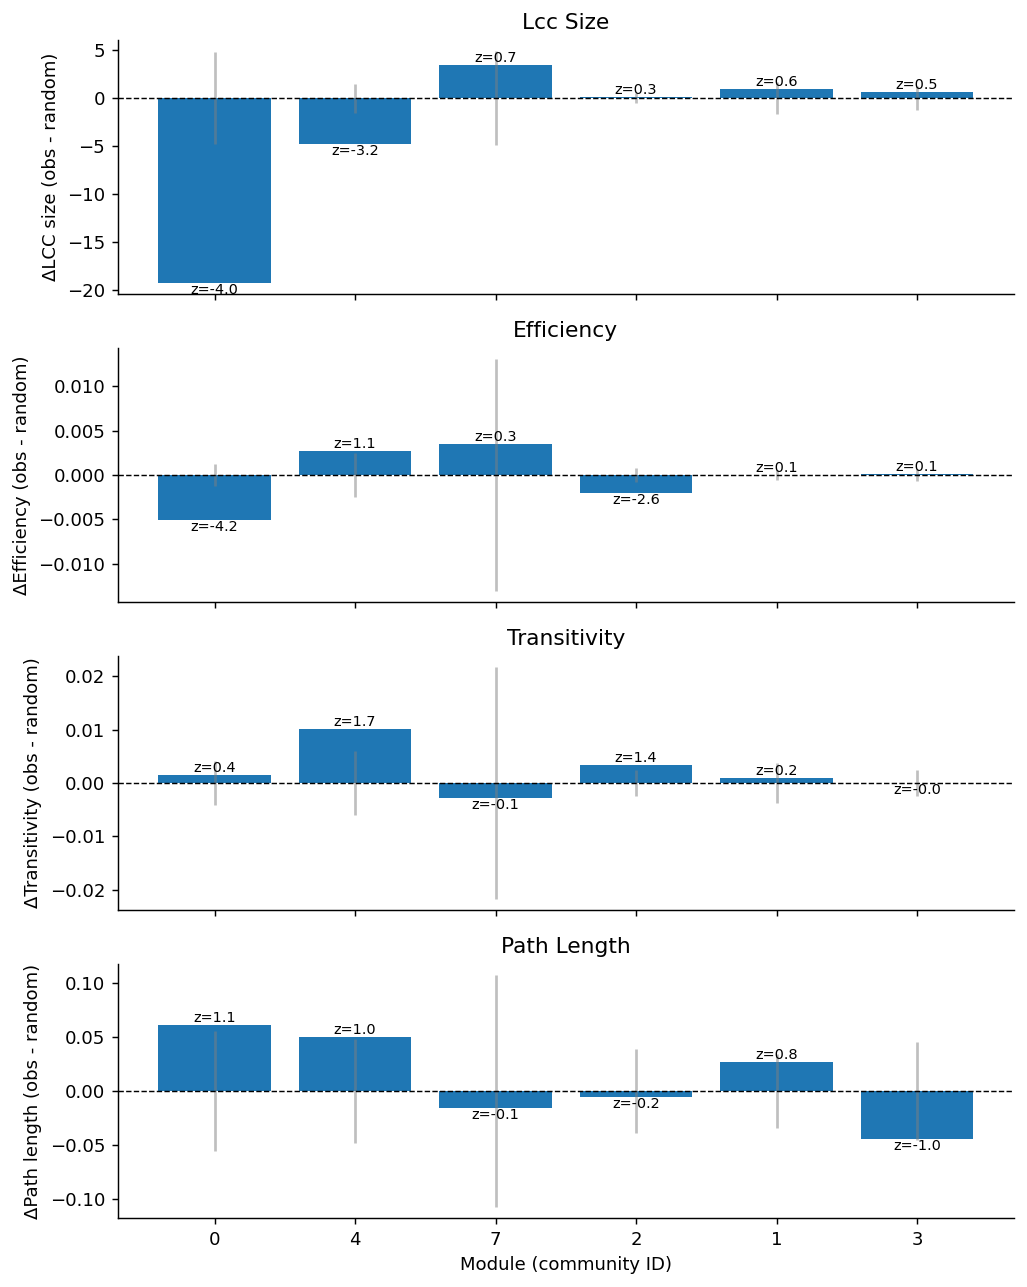

In [6]:
"""## Cell 6 – Visualise module collapse effects

Here we visualise the change in metrics after chaperone removal
relative to random removal.  Bar plots show, for each module, how
much the LCC size, efficiency, transitivity and path length deviate
from the random expectation.  Modules are sorted by number of
chaperones so that the largest proteostasis modules appear first.
Negative bars indicate that chaperone removal has a stronger negative
impact (e.g., larger drop in LCC size or efficiency) than random
removal.  Error bars denote one standard deviation of the random
distribution, converted to the same scale.
"""

# %%
import numpy as np

# Sort modules by number of chaperones
plot_df = module_results_df_sorted.copy().sort_values("n_chaperones", ascending=False)

metrics_to_plot = ["lcc_size", "efficiency", "transitivity", "path_length"]
ylabels = {
    "lcc_size": "ΔLCC size (obs - random)",
    "efficiency": "ΔEfficiency (obs - random)",
    "transitivity": "ΔTransitivity (obs - random)",
    "path_length": "ΔPath length (obs - random)",
}

# Create subplots for each metric
fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(8, 2.5 * len(metrics_to_plot)), sharex=True)
for ax, metric in zip(axes, metrics_to_plot):
    diffs = plot_df[f"{metric}_diff"]
    rand_sds = plot_df[f"{metric}_random_sd"]
    modules = plot_df["module"].astype(str)
    bars = ax.bar(modules, diffs)
    # Add error bars from random SDs (grey)
    ax.errorbar(modules, np.zeros_like(rand_sds), yerr=rand_sds, fmt='none', color='gray', alpha=0.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel(ylabels[metric])
    ax.set_title(metric.replace("_", " ").title())
    # Annotate bars with z-scores
    for rect, z in zip(bars, plot_df[f"{metric}_z"]):
        height = rect.get_height()
        if not math.isnan(z):
            ax.text(rect.get_x() + rect.get_width() / 2, height,
                    f"z={z:.1f}", ha="center",
                    va="bottom" if height >= 0 else "top",
                    fontsize=8)
plt.xlabel("Module (community ID)")
plt.tight_layout()
plt.show()

1. Module 0
This module contains 43 chaperones (largest proteostasis module).
LCC Size
ΔLCC ≈ −19
z ≈ −4.0
Interpretation:Removing chaperones breaks the module into many disconnected pieces.This is far worse than removing random proteins. Chaperones are structural glue inside this module.

Efficiency (measures how easily information travels)
ΔEfficiency ≈ −0.005
z ≈ −4.2
Interpretation: Without chaperones, average distances between proteins increase, communication becomes worse. Chaperones maintain efficient information flow.

Path Length
ΔPath length ≈ +0.06
Interpretation: Shortest paths become longer, network becomes less navigable

Transitivity
Near zero change.
Interpretation: Local triangles remain intact, suggesting that chaperones are not local clustering nodes. They connect clusters rather than forming them.

"""## Cell 7 – Interpretation guidelines

After running the above cells, you will have a DataFrame (`module_results_df_sorted`)
and a set of plots summarising how chaperone removal affects each
module relative to random removal.  Use the following guidelines
when interpreting the results:

- **LCC size:** A large negative difference indicates that removing
  chaperones causes the module to fragment more than expected.  A
  difference close to zero suggests that the module remains largely
  connected even after chaperones are deleted.

- **Efficiency:** Lower efficiency after chaperone removal (negative
  difference) means that communication within the module becomes
  less efficient (average path lengths increase) compared to random
  removal.  Modules with large drops are more dependent on
  chaperones for maintaining short paths.

- **Transitivity:** A positive difference implies that clustering
  decreases less (or increases more) after chaperone removal than
  expected by chance.  This can occur if chaperones connect
  clusters and their removal reduces inter-cluster links.  A
  negative difference suggests clustering drops more after
  chaperone removal.

- **Path length:** A positive difference means that average path
  lengths become longer after chaperone removal than under random
  removal.  This indicates that chaperones help maintain short
  paths locally.

Comparing modules reveals which proteostasis-related subsystems are
most reliant on chaperones.  For example, if a particular module
exhibits a large decline in efficiency and a large increase in path
length when chaperones are removed, it suggests that chaperones are
crucial for information flow within that subsystem.  Conversely,
modules with negligible differences are more robust to the loss of
chaperones, perhaps because other proteins can compensate.
"""

## Global network robustness emerges from multiple local proteostasis modules stabilized by chaperones.
- Chaperones are locally essential but globally distributed.
- Chaperones are concentrated within specific proteostasis modules of the yeast interactome. Removal of these proteins causes pronounced fragmentation and reduced efficiency within those modules, whereas other communities remain largely unaffected. These results suggest that chaperones function as local structural stabilizers of proteostasis subsystems rather than universal backbone nodes of the global network.